In [2]:
from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance, PayloadSchemaType, PointStruct, SparseVectorParams, Document, Prefetch, FusionQuery
from qdrant_client.http.models import models
import pandas as pd
import openai
import fastembed
from langsmith import traceable, get_current_run_tree

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages

from jinja2 import Template
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from instructor import from_openai
from openai import OpenAI
from langgraph.graph.message import add_messages

from utils.utils import get_tool_descriptions, format_ai_message
from typing import Annotated, List, Any, Dict
from pydantic import Field, BaseModel
from operator import add
import instructor

from IPython.display import Image, display
from pprint import pprint
import json

from fastmcp import Client

### List MCP tools from two MCP servers

In [32]:
client = Client("http://localhost:8001/mcp")


In [33]:
async with client:
    tools = await client.list_tools()
print(tools)

[Tool(name='get_formatted_product_context', title=None, description='Retrieve top matching products for a query and return formatted product context.\n\nArgs:\n    query: User search query describing the desired product(s).\n\nReturns:\n    Formatted product context entries from the product retriever.', inputSchema={'properties': {'query': {'type': 'string'}}, 'required': ['query'], 'type': 'object'}, outputSchema={'additionalProperties': True, 'type': 'object'}, icons=None, annotations=None, meta={'_fastmcp': {'tags': []}}, execution=None)]


In [34]:
print(tools[0].name)
print(tools[0].description)
print(tools[0].inputSchema)

get_formatted_product_context
Retrieve top matching products for a query and return formatted product context.

Args:
    query: User search query describing the desired product(s).

Returns:
    Formatted product context entries from the product retriever.
{'properties': {'query': {'type': 'string'}}, 'required': ['query'], 'type': 'object'}


In [37]:
async with client:
    response = await client.call_tool(
        "get_formatted_product_context",
        {"query": "get me top laptops"}
    )

In [40]:
print(response.content[0].text)

["Product ID: B09QS7W8G5 - Description: HP 2022 Newest Pavilion 15.6\" FHD 1080P IPS Laptop, 8-Core AMD Ryzen 7-5700U(Up to 4.3GHz, Beat i7-1180G7), 32GB RAM, 1TB NVMe SSD, Numpad, HDMI, WiFi, USB-A&C, Fast Charge, Audio by B&O, Win11 ['We sell computers with upgraded configurations. If the computer has modifications (listed above), then the manufacturer box is opened for it to be tested and inspected and to install the upgrades to achieve the specifications as advertised. If no modifications are listed, the item is unopened and untested. Defects & blemishes are significantly reduced by our in-depth inspection & testing. Microprocessor: AMD Ryzen 7 5700U (1.8 GHz base clock, up to 4.3 GHz max boost clock, 8 MB L3 cache, 8 cores, 16 threads) Chipset: AMD Integrated SoC Memory: 32GB DDR4 RAM Video graphics: AMD Radeon Graphics, Integrated Hard drive: 1TB PCIe NVMe M.2 SSD Display: 15.6\" diagonal, FHD (1920 x 1080), IPS, micro-edge, BrightView, 250 nits, 45% NTSC Wireless connectivity: I

### Functions to extract tool defintions from MCP servers

In [41]:
def parse_docstring_params(docstring: str) -> Dict[str, str]:
    """Extract parameter descriptions from docstring (handles both Args: and Parameters: formats)."""
    params = {}
    lines = docstring.split('\n')
    in_params = False
    current_param = None
    
    for line in lines:
        stripped = line.strip()
        
        # Check for parameter section start
        if stripped in ['Args:', 'Arguments:', 'Parameters:', 'Params:']:
            in_params = True
            current_param = None
        elif stripped.startswith('Returns:') or stripped.startswith('Raises:'):
            in_params = False
        elif in_params:
            # Parse parameter line (handles "param: desc" and "- param: desc" formats)
            if ':' in stripped and (stripped[0].isalpha() or stripped.startswith(('-', '*'))):
                param_name = stripped.lstrip('- *').split(':')[0].strip()
                param_desc = ':'.join(stripped.lstrip('- *').split(':')[1:]).strip()
                params[param_name] = param_desc
                current_param = param_name
            elif current_param and stripped:
                # Continuation of previous parameter description
                params[current_param] += ' ' + stripped
    
    return params

In [42]:
async def get_tool_descriptions_from_mcp_servers(mcp_servers: list[str]) -> list[dict]:

    tool_descriptions = []

    for server in mcp_servers:

        client = Client(server)

        async with client:

            tools = await client.list_tools()

            for tool in tools:
                
                result = {
                    "name": "",
                    "description": "",
                    "parameters": {"type": "object", "properties": {}},
                    "required": [],
                    "returns": {"type": "string", "description": ""},
                    "server": server
                }

                result["name"] = tool.name
                result["required"] = tool.inputSchema.get("required", [])

                ## Get Description

                description = tool.description.split("\n\n")[0]
                result["description"] = description


                ## Get Returns

                returns = tool.description.split("Returns:")[1].strip()
                result["returns"]["description"] = returns

                ## Get parameters

                property_descriptions = parse_docstring_params(tool.description)
                properties = tool.inputSchema.get("properties", {})
                for key, value in properties.items():
                    properties[key]["description"] = property_descriptions.get(key, "")

                result["parameters"]["properties"] = properties

                tool_descriptions.append(result)

    return tool_descriptions

In [44]:
mcp_servers = ["http://localhost:8001/mcp", "http://localhost:8002/mcp"]
tool_descriptions = await get_tool_descriptions_from_mcp_servers(mcp_servers)


In [46]:
tool_descriptions

[{'name': 'get_formatted_product_context',
  'description': 'Retrieve top matching products for a query and return formatted product context.',
  'parameters': {'type': 'object',
   'properties': {'query': {'type': 'string',
     'description': 'User search query describing the desired product(s).'}}},
  'required': ['query'],
  'returns': {'type': 'string',
   'description': 'Formatted product context entries from the product retriever.'},
  'server': 'http://localhost:8001/mcp'},
 {'name': 'get_formatted_reviews',
  'description': 'Retrieve top matching reviews for a list of product IDs and return formatted reviews context.\nArgs:\n    query: User search query describing the desired reviews.\n    product_ids: A list of product IDs (parent_asin) for which reviews are to be retrieved. \n    Returns:\n    Formatted reviews context entries from the review retriever.',
  'parameters': {'type': 'object',
   'properties': {'query': {'type': 'string',
     'description': 'User search query d

## Agent integration with new MCP server tools

In [50]:
from typing import Annotated, List, Any, Dict
from pydantic import Field
from operator import add

class Toolcall(BaseModel):
    name: str
    arguments: dict
    server: str
    
class RAGUsedContext(BaseModel):
    id: str = Field(description="The ID of the item used to answer the question")
    description: str = Field(description="Short description of the item used to answer the question")

class AgentResponse(BaseModel):
    answer: str = Field(description="Answer to the question.")
    references: list[RAGUsedContext] = Field(description="List of items used to answer the question.")
    final_answer: bool = False
    tool_calls: List[Toolcall] = []

class State(BaseModel):
    messages: Annotated[List[Any], add_messages] = []
    user_query: str = ""
    expanded_queries: List[str] = []
    final_answer: bool = False
    iteration: int = 0
    available_tools: List[Dict[str, Any]] = []
    answer: str = ""
    references: Annotated[List[RAGUsedContext], add] = []
    query_relevant: bool = False
    tool_calls: List[Toolcall] = []

class QueryRelevanceResponse(BaseModel):
    query_relevant: bool
    reason: str

class QueryRewriteResponse(BaseModel):
    search_queries: List[str]
    
class AggregationResponse(BaseModel):
    answer: str = Field(description="The answer to the question in a list format.")

In [51]:
def create_embeddings(text, model="text-embedding-3-small"):
   
    response = openai.embeddings.create(
        model=model,
        input=text
    )
        
    return response.data[0].embedding

In [52]:
@traceable(name="query_rewriter_node", 
description="This function rewrites the query to be more specific to include multiple statements",
run_type="prompt"
)
def query_rewriter_node(state: State) -> str:
    """
    This function rewrites the query to be more specific to include multiple statements
    """
    
    prompt_template = """
    ### ROLE
    You are a Shopping Intent Extraction Agent.
    Your task is to analyze a user's request and split it into distinct, standalone product search statements.

    ### GUIDELINES
    1. **Identify Entities:** Look for distinct people or needs (e.g., "for me", "for my kid", "for my wife").
    2. **Segment Requests:**
    - If multiple items are requested, split them into separate strings.
    - **CRITICAL:** If the user asks for a single item or makes a simple statement, return a list with THAT SINGLE item only. Do not invent extra queries.
    3. **Refine & Standardize:**
    - Convert colloquial phrases into searchable terms (e.g., "nice toys" -> "toys for kids").
    - If the query refers to previous context (e.g., "show me the red ones", "sort by price"), preserve the user's specific constraint (e.g., "red products", "sort by price") without hallucinating new products.
    4. **Anti-Hallucination:**
    - **NEVER** use the content from the "Examples" section below in your final output.
    - **NEVER** make up products if the user did not mention them.

    ### OUTPUT FORMAT
    Return a raw JSON object with a key "search_queries" containing a list of strings.

    ### EXAMPLES (For instruction only - DO NOT COPY)

    Input: "I need smart watch. My kid needs nice toys. My wife want home appliances."
    Output:
    {
        "search_queries": [
            "Smart watch for adults",
            "Toys for kids",
            "Home appliances for women"
        ]
    }

    Input: "Looking for a gaming laptop for myself and a pink ipad for my daughter."
    Output:
    {
        "search_queries": [
            "Gaming laptop",
            "Pink iPad for girls"
        ]
    }

    Input: "Show me more options"
    Output:
    {
        "search_queries": [
            "Show me more options"
        ]
    }

    ### CURRENT TASK
    Input: {{ query }}
    Output:
    """
        
    prompt = Template(prompt_template).render(query=state.messages[-1].content)
    
    client = instructor.from_openai(OpenAI())
    
    response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4o-mini",
        response_model=QueryRewriteResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.4
    )
    ai_message = AIMessage(content=response.search_queries)
    return {
        "messages": ai_message,
        "expanded_queries": response.search_queries
    }

/Users/kashvi/repos/ai-bootcamp-agentic-rag/.venv/lib/python3.12/site-packages/langsmith/run_helpers.py:531: DeprecationWarning: The following keyword arguments are not recognized and will be ignored: ['description'].
  warnings.warn(


In [53]:
# making retrieve_embedding_data a retriever node for parallel execution
from typing import Dict

def retrieve_embedding(query: str) -> List[str]:
    """
    Retrieves a list of relevant product context strings from a Qdrant database using hybrid search (embedding and BM25 fusion) based on the given user query.

    Args:
        query (str): The user's search query for desired product(s).

    Returns:
        List[str]: Each string contains the product ID, description, and average rating, formatted as:
            'Product ID: <ASIN> - Description: <description> - Rating: <rating>'
    """
    
    qd_client = QdrantClient(url="http://localhost:6333")
    
    collection_name = "amazon_items-collection-hybrid-02"
    k=5
    
    querry_embeddings = create_embeddings(query)
    
    response = qd_client.query_points(
        collection_name=collection_name,
        prefetch=[Prefetch(
            query=querry_embeddings,
            using="text-embedding-3-small",
            limit=20),
            Prefetch(
                query=Document(text=query, model="qdrant/bm25"),
                using="bm25",
                limit=20)
            ],
        query=FusionQuery(fusion="rrf"),
        limit=k,
    )
    retrieved_context_ids = []
    retrieved_context = []
    retrieved_scores = []
    retrieved_context_ratings = []
    
    for point in response.points:
        retrieved_context_ids.append(point.payload["parent_asin"])
        retrieved_context.append(point.payload["description"])
        retrieved_scores.append(point.score)
        retrieved_context_ratings.append(point.payload["average_rating"])

    retrieved_contextdata = []
    for item, context, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        product_context = f"Product ID: {item} - Description: {context} - Rating: {rating}"
        retrieved_contextdata.append(product_context)
    
    return retrieved_contextdata    

In [54]:
# add router node to evaluate the user query and decide the next node to execute
def router_node(state: State) -> State:
    """
    This function evaluates the user query and decides the next node to execute
    """
    prompt_template = """
    You are a Query Relevance Validator for a specific e-commerce product catalog.
    Your job is to classify the user's intent and determine if we need to ask for clarification before proceeding.

    ### Instructions:
    1. **Analyze Intent:** Look at the User Query below.
    2. **Determine Relevance:** - **RELEVANT (true):** The user is asking about buying products, features, comparisons, prices, or inventory.
    - **NOT RELEVANT (false):** The user is asking about topics completely unrelated to shopping (e.g., "How's the weather?").
    3. **Stock & Availability Check:** - If the user asks specifically about **product stock** or **availability** (e.g., "Is this in stock?", "Do you have inventory?"), you MUST request clarification.
    - Set `clarification_needed` to `true`.
    - In the `reason` field, draft a polite clarification question (e.g., "Could you specify which product or store location you are asking about?").
    4. **Output Format:** You must output valid JSON only.

    ### Schema:
    {
        "query_relevant": boolean,
        "clarification_needed": boolean,
        "reason": "string"
    }

    ### User Query:
    {{ question }}

    ### JSON Response:
    """
    
    prompt = Template(prompt_template).render(question=state.messages[-1].content)
    
    client = instructor.from_openai(OpenAI())
    
    response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4o-mini",
        response_model=QueryRelevanceResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.4
    )
    
    return {
        "query_relevant": response.query_relevant,
        "answer": response.reason
    }

In [55]:
# define the conditional edge to decide the query expansion or end state
from typing import Literal
def router_conditional_edge(state: State) -> Literal["query_rewriter", END]:
    """
    This function decides the next node to execute based on the user query
    """
    if state.query_relevant:
        return "query_rewriter"
    else:
        return END

In [56]:
from langchain_core.messages import AIMessage, ToolMessage

def sanitize_history(messages):
    """
    Scans the entire message history. 
    If an AIMessage has tool_calls but is NOT followed by a ToolMessage,
    we strip the tool_calls from it to prevent OpenAI 400 errors.
    """
    sanitized_msgs = []
    
    # Iterate through all messages
    for i, msg in enumerate(messages):
        
        # Check if this is an AI Message with tool calls
        if isinstance(msg, AIMessage) and msg.tool_calls:
            
            # Look ahead: Is the NEXT message a ToolMessage?
            is_valid_chain = False
            if i + 1 < len(messages):
                next_msg = messages[i+1]
                if isinstance(next_msg, ToolMessage):
                    is_valid_chain = True
            
            if is_valid_chain:
                # It's a valid pair (AI -> Tool). Keep it.
                sanitized_msgs.append(msg)
            else:
                # It's BROKEN (AI -> Human or AI -> End). 
                # Fix: Create a clean copy WITHOUT tool_calls.
                print(f"⚠️ Repairing broken history at index {i}: Removing orphaned tool_calls.")
                
                # We keep the text content (if any), but remove the toxic tool_calls
                clean_msg = msg.model_copy(update={"tool_calls": [], "id": msg.id})
                
                # Only add it if it actually has text (otherwise it's an empty message)
                if clean_msg.content:
                    sanitized_msgs.append(clean_msg)
        
        # If it's a ToolMessage that was orphaned (no previous AI call), 
        # OpenAI usually tolerates this, or you can filter it too. 
        # For now, we just pass non-AI messages through.
        else:
            sanitized_msgs.append(msg)
            
    return sanitized_msgs

In [78]:
# define agent node which can use RAG pipeline to perform search on the products 
from langgraph.prebuilt import tools_condition
from langchain_core.messages import RemoveMessage
from langchain_openai import ChatOpenAI

@traceable(name="agent_node", 
description="This function uses the RAG pipeline to perform search on the products",
run_type="retriever"
)
def agent_node(state: State) -> State:
    """
    This function uses the RAG pipeline to perform search on the products
    """
    
    
    search_agent_prompt = """
    ### ROLE & OBJECTIVE
        You are an intelligent Shopping Assistant specialized in answering customer questions about in-stock products. Your goal is to provide accurate, detailed product information based strictly on the data retrieved from your tools.

        ### AVAILABLE TOOLS
        <Available tools>
        {{ available_tools | tojson }}
        </Available tools>

        ### CRITICAL PROTOCOL (READ CAREFULLY)
        You operate in a strict loop. You must decide whether to **fetch data** or **provide a final answer**. You cannot do both in the same turn.

        1. **Tool Usage State (`final_answer = false`)**:
        - If you need information to answer the user, you MUST generate `tool_calls`.
        - **Decompose** complex user queries into multiple sub-queries if necessary.
        - **Parallelize** requests: If multiple tools (or multiple calls to the same tool) are needed, invoke them all in this single turn.
        - **Do not** attempt to answer the question yet.
        - **Do not** announce what you are doing (e.g., "I will check the stock"). Just return the tool calls.

        2. **Final Answer State (`final_answer = true`)**:
        - Only enter this state when you have sufficient information from previous tool outputs.
        - In this state, `tool_calls` MUST be an empty list `[]`.

        ### TOOL CALLING FORMAT
        When invoking tools, you must use this **exact JSON structure**. All parameters must be nested inside an `arguments` object:

        {
            "name": "tool_name",
            "arguments": {
                "param1": "value1",
                "param2": "value2"
            }
        }

        ### CRITICAL NAMING RULES (DO NOT IGNORE)
        1. **EXACT MATCH:** Use the **exact tool name** as listed in the "Available tools" section.
        2. **NO PREFIXES:** You are strictly FORBIDDEN from adding prefixes like `functions.`, `tool.`, or `cmd.` to the name.
        - ❌ WRONG: "functions.get_formatted_reviews_context"
        - ✅ CORRECT: "get_formatted_reviews_context"

        ### RESPONSE GUIDELINES
        - **Source of Truth:** Answer ONLY using the outputs provided by tools.
        - **NO EXAMPLE USAGE:** You are strictly FORBIDDEN from using any data, product names, or IDs found in the "EXAMPLES" section below. Real data must come ONLY from tool execution results.
        - **Terminology:** Never refer to "context," "chunks," or "tools" in your final answer. Refer to the data as "available products" or "our stock."
        - **Scope:** If a question is unrelated to product stock, ask for clarification.
        - **Detail:** Product specifications must be detailed and presented in **bullet points**.

        ### FINAL OUTPUT SCHEMA
        Your response must strictly adhere to the following schema:

        * **answer** (str): The detailed response to the user.
        - If `final_answer` is `false`, this should be empty or a brief holding message (though usually ignored).
        - If `final_answer` is `true`, this is your comprehensive reply.
        * **references** (List[dict]): A list of source items used to generate the answer.
        - Each item must include an `id` and a `description` (short summary with item name).
        - Include references for ALL chunks used to compile the answer.
        * **final_answer** (bool):
        - `false` if you are making tool calls.
        - `true` if you are providing the final response.
        * **tool_calls** (List[dict]): A list of tool calls formatted as specified above (or empty if answering).

        ### EXAMPLES (DO NOT USE THIS DATA IN OUTPUT)

        **Scenario 1: Need Data (Tool Call)**
        User: "Show me cool kids' toys."
        Output:
        {
            "answer": "",
            "references": [],
            "final_answer": false,
            "tool_calls": [
                {
                    "name": "get_formatted_item_context",
                    "arguments": { "query": "cool kids toys", "top_k": 5 }
                }
            ]
        }

        **Scenario 2: Have Data (Final Answer)**
        User: "Tell me about the Lego set."
        (Context has been retrieved)
        Output:
        {
            "answer": "We have the **Galactic Explorer Lego Set** in stock. Features include:\n- 1500 pieces\n- Retractable landing gear...",
            "references": [{"id": "123", "description": "Lego Galactic Explorer set"}],
            "final_answer": true,
            "tool_calls": []
        }
    """
    
    prompt = Template(search_agent_prompt).render(available_tools=state.available_tools)

    messages = sanitize_history(state.messages)

    conversation = []

    for message in messages:
        conversation.append(convert_to_openai_messages(message))
        
    client = instructor.from_openai(OpenAI())

    response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=AgentResponse,
        messages=[{"role": "system", "content": prompt}, *conversation],
        temperature=0.5,
    )
    
    ai_message = format_ai_message(response)

    return {
        "messages": [ai_message],
        "tool_calls": response.tool_calls,
        "iteration": state.iteration + 1,
        "answer": response.answer,
        "final_answer": response.final_answer,
        "references": response.references
    }

# define custom route edge to decide the tool call or agent node or aggregation node
def custome_route_edge(state: State) -> Literal["tools", END]:
    """
    This function decides the next node to execute based on the user query
    """
    #print(state.messages)
    
    if state.final_answer:
        return "end"
    
    if state.iteration > 2:
        return "end"
    
    if len(state.tool_calls) > 0:
        return "tools"
    
    return "end"
    

/Users/kashvi/repos/ai-bootcamp-agentic-rag/.venv/lib/python3.12/site-packages/langsmith/run_helpers.py:531: DeprecationWarning: The following keyword arguments are not recognized and will be ignored: ['description'].
  warnings.warn(


### Custom MCP tool Node (without using langgraph framework)

In [69]:
async def mcp_tool_node(state: State) -> str:
    """
    This function executes the tool calls and returns the results
    """
    tool_messages = []
    
    for i, tc in enumerate(state.tool_calls):
        client = Client(tc.server)
    
        async with client:
            response = await client.call_tool(
                    tc.name,
                    tc.arguments
                )
            tool_message = ToolMessage(
                content = response.content[0].text,
                tool_call_id=f"call_{i}"
            )
            tool_messages.append(tool_message)
        
    return {
        "messages": tool_messages,
    }

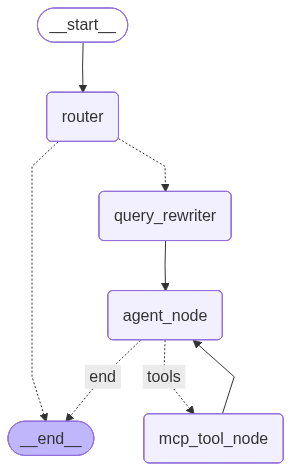

In [79]:
graphbuilder2 = StateGraph(State)

mcp_servers = ["http://localhost:8001/mcp", "http://localhost:8002/mcp"]
tool_descriptions = await get_tool_descriptions_from_mcp_servers(mcp_servers)

tools=[retrieve_embedding]

tools_node = ToolNode(tools=tools)
graphbuilder2.add_node("router", router_node)
graphbuilder2.add_node("query_rewriter", query_rewriter_node)
graphbuilder2.add_node("agent_node", agent_node)
graphbuilder2.add_node("mcp_tool_node", mcp_tool_node)

graphbuilder2.add_edge(START, "router")
graphbuilder2.add_conditional_edges("router", router_conditional_edge, {"query_rewriter": "query_rewriter", END: END})
graphbuilder2.add_edge("query_rewriter", "agent_node")
graphbuilder2.add_conditional_edges("agent_node", custome_route_edge, {"tools": "mcp_tool_node", "end": END})
graphbuilder2.add_edge("mcp_tool_node", "agent_node")

agg_graph_1 = graphbuilder2.compile()

display(Image(agg_graph_1.get_graph().draw_mermaid_png()))

In [80]:
initial_state = {
    "messages": [{"role": "user", "content": "top laptops for me. Show me the kid toys as well. Nice bags for my daughter?"}],
    "available_tools": tool_descriptions,
    "user_query": ""}

result = await agg_graph_1.ainvoke(initial_state)

pprint(result["answer"])

('Here are some top products from our stock based on your requests:\n'
 '\n'
 'Top Laptops:\n'
 '- 2022 Newest Lenovo IdeaPad 1 Laptop: 14" Anti-Glare Display, Intel '
 'Quad-Core Processor, Intel UHD Graphics, 4GB RAM, 128GB PCIe SSD, Windows 11 '
 '+ Office 365 1-Year Subscription.\n'
 '- jumper Laptop: 16 Inch FHD IPS Display, Intel Celeron Quad Core CPU, 4GB '
 'DDR4, 128GB Storage, Windows 11, Office 365 1-Year Subscription, Numeric '
 'Keypad, 4 Stereo Speakers.\n'
 '- LanBaiLan Compatible Case for MacBook Air 13 inch with Bling Silver Laptop '
 'Case & Keyboard Cover.\n'
 '\n'
 'Toys for Kids:\n'
 '- AirTag Bracelet for AirTags: Toddler DIY Silicone Bracelets, Hidden '
 'Anti-Lost Holder, Waterproof, Adjustable Length Band for Girls (Pink, '
 'Yellow).\n'
 '- TUNEAKE Kids Headphones: Over Ear, Volume Limited 94dB, Foldable, '
 'Adjustable, Pink color.\n'
 '- QearFun Dinosaur Headphones: Wired Headphones with Microphone, Noise '
 'Cancelling, Adjustable Headband for Kids.\n'
 '- 

In [81]:
result

{'messages': [HumanMessage(content='top laptops for me. Show me the kid toys as well. Nice bags for my daughter?', additional_kwargs={}, response_metadata={}, id='cb91b48c-0d7f-4f5f-b0d0-ef416fd70062'),
  AIMessage(content=['Top laptops for adults', 'Toys for kids', 'Bags for girls'], additional_kwargs={}, response_metadata={}, id='1e77f8e8-54a6-4411-90c5-1f836442024e', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='', additional_kwargs={}, response_metadata={}, id='4e32a56f-3f40-4979-9236-aa3a2b4daa29', tool_calls=[{'name': 'get_formatted_product_context', 'args': {'query': 'top laptops'}, 'id': 'call_0', 'type': 'tool_call'}, {'name': 'get_formatted_product_context', 'args': {'query': 'kids toys'}, 'id': 'call_1', 'type': 'tool_call'}, {'name': 'get_formatted_product_context', 'args': {'query': 'nice bags for girls'}, 'id': 'call_2', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='["Product ID: B015TPLFFO - Description: 2022 Newest Lenovo IdeaPad 1 